In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e6/train.csv
/kaggle/input/competitions/playground-series-s6e6/test.csv


In [2]:
# Reading dataset
df_train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/train.csv')
df_test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv')

# Data Overview

In [3]:
df_train.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [4]:
df_test.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


In [5]:
print(f"shape of train dataset is {df_train.shape}")
print(f"shape of test dataset is {df_test.shape}")


shape of train dataset is (577347, 12)
shape of test dataset is (247435, 11)


# EDA

In [6]:
# Summery of eah column
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


In [7]:
df_train.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [8]:
# Checking for Null-Values

df_train.isnull().sum()

id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

In [9]:
# checking for unique values in each column
def unique_value(dataset):
    columns = dataset.columns

    for col in columns:
        print(f"Total number of unique values in {col}: {dataset[col].nunique()}")


unique_value(df_train)
print('\n\n')
unique_value(df_test)

Total number of unique values in id: 577347
Total number of unique values in alpha: 439819
Total number of unique values in delta: 444062
Total number of unique values in u: 577347
Total number of unique values in g: 577347
Total number of unique values in r: 577347
Total number of unique values in i: 577347
Total number of unique values in z: 577347
Total number of unique values in redshift: 573975
Total number of unique values in spectral_type: 4
Total number of unique values in galaxy_population: 2
Total number of unique values in class: 3



Total number of unique values in id: 247435
Total number of unique values in alpha: 200893
Total number of unique values in delta: 201819
Total number of unique values in u: 247435
Total number of unique values in g: 247435
Total number of unique values in r: 247435
Total number of unique values in i: 247435
Total number of unique values in z: 247435
Total number of unique values in redshift: 246031
Total number of unique values in spectral_typ

In [10]:
def val_count(dataset, column_name):
    for col in column_name:
        count = dataset[col].value_counts()
        percentage = dataset[col].value_counts(normalize = True) * 100

        result = pd.DataFrame({
            "count" : count,
            "percentage (%)" : percentage.round(2)
        })
        print(f"Values for {col} column: \n")
        print(result)
        print('='*90)


In [11]:
cat_col = ['spectral_type','galaxy_population','class']
val_count(df_train, cat_col)

Values for spectral_type column: 

                count  percentage (%)
spectral_type                        
M              303323           52.54
A/F            122122           21.15
G/K            108546           18.80
O/B             43356            7.51
Values for galaxy_population column: 

                    count  percentage (%)
galaxy_population                        
Red_Sequence       319565           55.35
Blue_Cloud         257782           44.65
Values for class column: 

         count  percentage (%)
class                         
GALAXY  377480           65.38
QSO     117143           20.29
STAR     82724           14.33


In [12]:
num_col = []
num_col = df_train.select_dtypes(include=['number']).columns.tolist()
num_col.remove("id")
print(num_col)


['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']


alternative 1: 
num_col = []
for col in df_train.columns:
    if 'int' in str(df_train[col].dtype) or 'float' in str(df_train[col].dtype):
        num_col.append(col)
print(num_col)

altrnative 2:
num_col = [col for col in df_train.columns if 'int' in str(df_train[col].dtype) or 'float' in str(df_train[col].dtype)]
print(num_col)

In [13]:
# Checking relation between features and target!!
from sklearn.feature_selection import SelectKBest, f_classif

m = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

X_data = df_train[m] 
n = df_train['class']

# Compute ANOVA F-value (higher F-value = higher correlation/importance)
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_data, n) 

feature_scores = pd.Series(selector.scores_, index=m)
print(feature_scores.sort_values(ascending=False))

# Give importance to this one for feature selection

redshift    352900.373856
z            94881.321595
i            71806.562164
u            51307.845634
r            36471.209861
g            33737.837117
delta         3412.794874
alpha          631.115100
dtype: float64


In [14]:
# checking mean relation via group by:
# 1. Group by 'class' and calculate the mean for all numerical columns at once
mean_df = df_train.groupby('class')[num_col].mean()

column_scores = mean_df.sum().sort_values(ascending=False)

print(column_scores)


alpha       552.402070
delta        66.703996
u            65.674304
g            62.021493
r            59.855174
i            58.666086
z            57.939216
redshift      2.452782
dtype: float64


In [15]:
# checking for multi-colinearity!
corr_matrix = df_train[num_col].corr()

print(corr_matrix.round(2))

          alpha  delta     u     g     r     i     z  redshift
alpha      1.00   0.14 -0.02 -0.04 -0.04 -0.03 -0.02      0.01
delta      0.14   1.00 -0.03 -0.01 -0.00  0.00  0.00      0.05
u         -0.02  -0.03  1.00  0.83  0.66  0.52  0.44      0.08
g         -0.04  -0.01  0.83  1.00  0.91  0.81  0.73      0.24
r         -0.04  -0.00  0.66  0.91  1.00  0.95  0.91      0.39
i         -0.03   0.00  0.52  0.81  0.95  1.00  0.97      0.47
z         -0.02   0.00  0.44  0.73  0.91  0.97  1.00      0.48
redshift   0.01   0.05  0.08  0.24  0.39  0.47  0.48      1.00


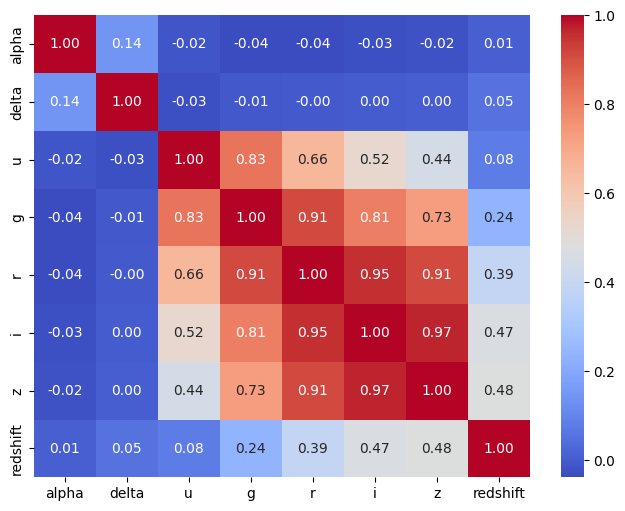

In [16]:
# visuilization

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    df_train[num_col].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.show()

Tree based algo handel multi-colinearity by themself!!
-> if using liner model then check for it!!

# Feature Engineering

In [17]:
# # binary-encoding
# df_train['galaxy_population'] = df_train['galaxy_population'].map({
#     'Red_Sequence' : 0,
#     'Blue_Cloud' : 1
# })

In [18]:
# # one-hot encoding;
# # Don't do encoding for target variable!!

# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder

# ct = ColumnTransformer(
#     transformers=[
#         ('ohe', OneHotEncoder(sparse_output=False), ['spectral_type'])
#     ],
#     remainder='passthrough',
#     verbose_feature_names_out=False
# )
# encoded_array = ct.fit_transform(df_train)
# df_train = pd.DataFrame(encoded_array, columns=ct.get_feature_names_out())

In [19]:
# # Trarget encoding -> we do LabelEncoding

# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()

# df_train['class'] = le.fit_transform(df_train['class'])

# print(le.classes_)

In [20]:
# df_train = df_train.drop(columns=['id'])

In [21]:
# df_train.head()

# Pipeline of Feature Engieering in correct way!

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
import pandas as pd

# Step 1: Separate features and target
X_train = df_train.drop(columns=['id', 'class'])
y_train = df_train['class']

X_test = df_test.drop(columns=['id'])

# Step 2: Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(sparse_output=False), ['spectral_type']),
        ('binary', OrdinalEncoder(categories=[['Red_Sequence', 'Blue_Cloud']]), ['galaxy_population']),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

# Step 3: Fit on train, transform both
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Step 4: Convert back to DataFrame
X_train_transformed = pd.DataFrame(X_train_transformed, columns=preprocessor.get_feature_names_out())
X_test_transformed = pd.DataFrame(X_test_transformed, columns=preprocessor.get_feature_names_out())

# Step 5: Encode target separately
le = LabelEncoder()
y_train = le.fit_transform(y_train)

# Cross Validation | Train | evaluate

#### Steps:

##### 1. Define X and y
##### 2. Preprocess X 
##### 3. Import and define the model
##### 4. Cross-validate to evaluate performance -> answers "how good is my model?" using CV
##### 5. Fit on full training data -> trains the final model on all data for actual predictions
##### 6. Transform test data using the same ct
##### 7. Predict on test

In [23]:
# # Step 1: done in pipeline
# X_train = df_train.drop(columns = ['id','class'])
# y_train = df_train['class']

In [24]:
# Step 2:
# Already done -> feature engineering like OHE, BIN-Encoding and all...
# Update: Done neately in pipeline

In [27]:
# Step 3: Defining Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100, 
    criterion='gini', 
    max_depth=None, 
    min_samples_split=2, 
    min_samples_leaf=1, 
    max_features='sqrt', 
    bootstrap=True, 
    random_state=None, 
    n_jobs=-1
)


In [ ]:
# Step 4: Cross-validate

from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train_transformed, y_train, cv=skf, scoring='accuracy')
print(f"CV Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")

In [ ]:
# Step 5: training the model
model.fit(X_train_transformed,y_train)

In [ ]:
# Step 6: Transform test data -> done in Pipeline

In [ ]:
# Step 7: Predict
predictions = model.predict(X_test_transformed)
print(predictions)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

X = df_train.drop(columns=['class'])
y = df_train['class']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(RandomForestClassifier(), X, y, cv=skf, scoring='accuracy')

print(f"CV Scores: {scores}")
print(f"Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")